Mounted at /content/drive
Starting Tiny NN Training...
2026-02-13 06:54:20.835190: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770965660.855893    1655 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770965660.862645    1655 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770965660.878051    1655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770965660.878076    1655 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770965660.878080   

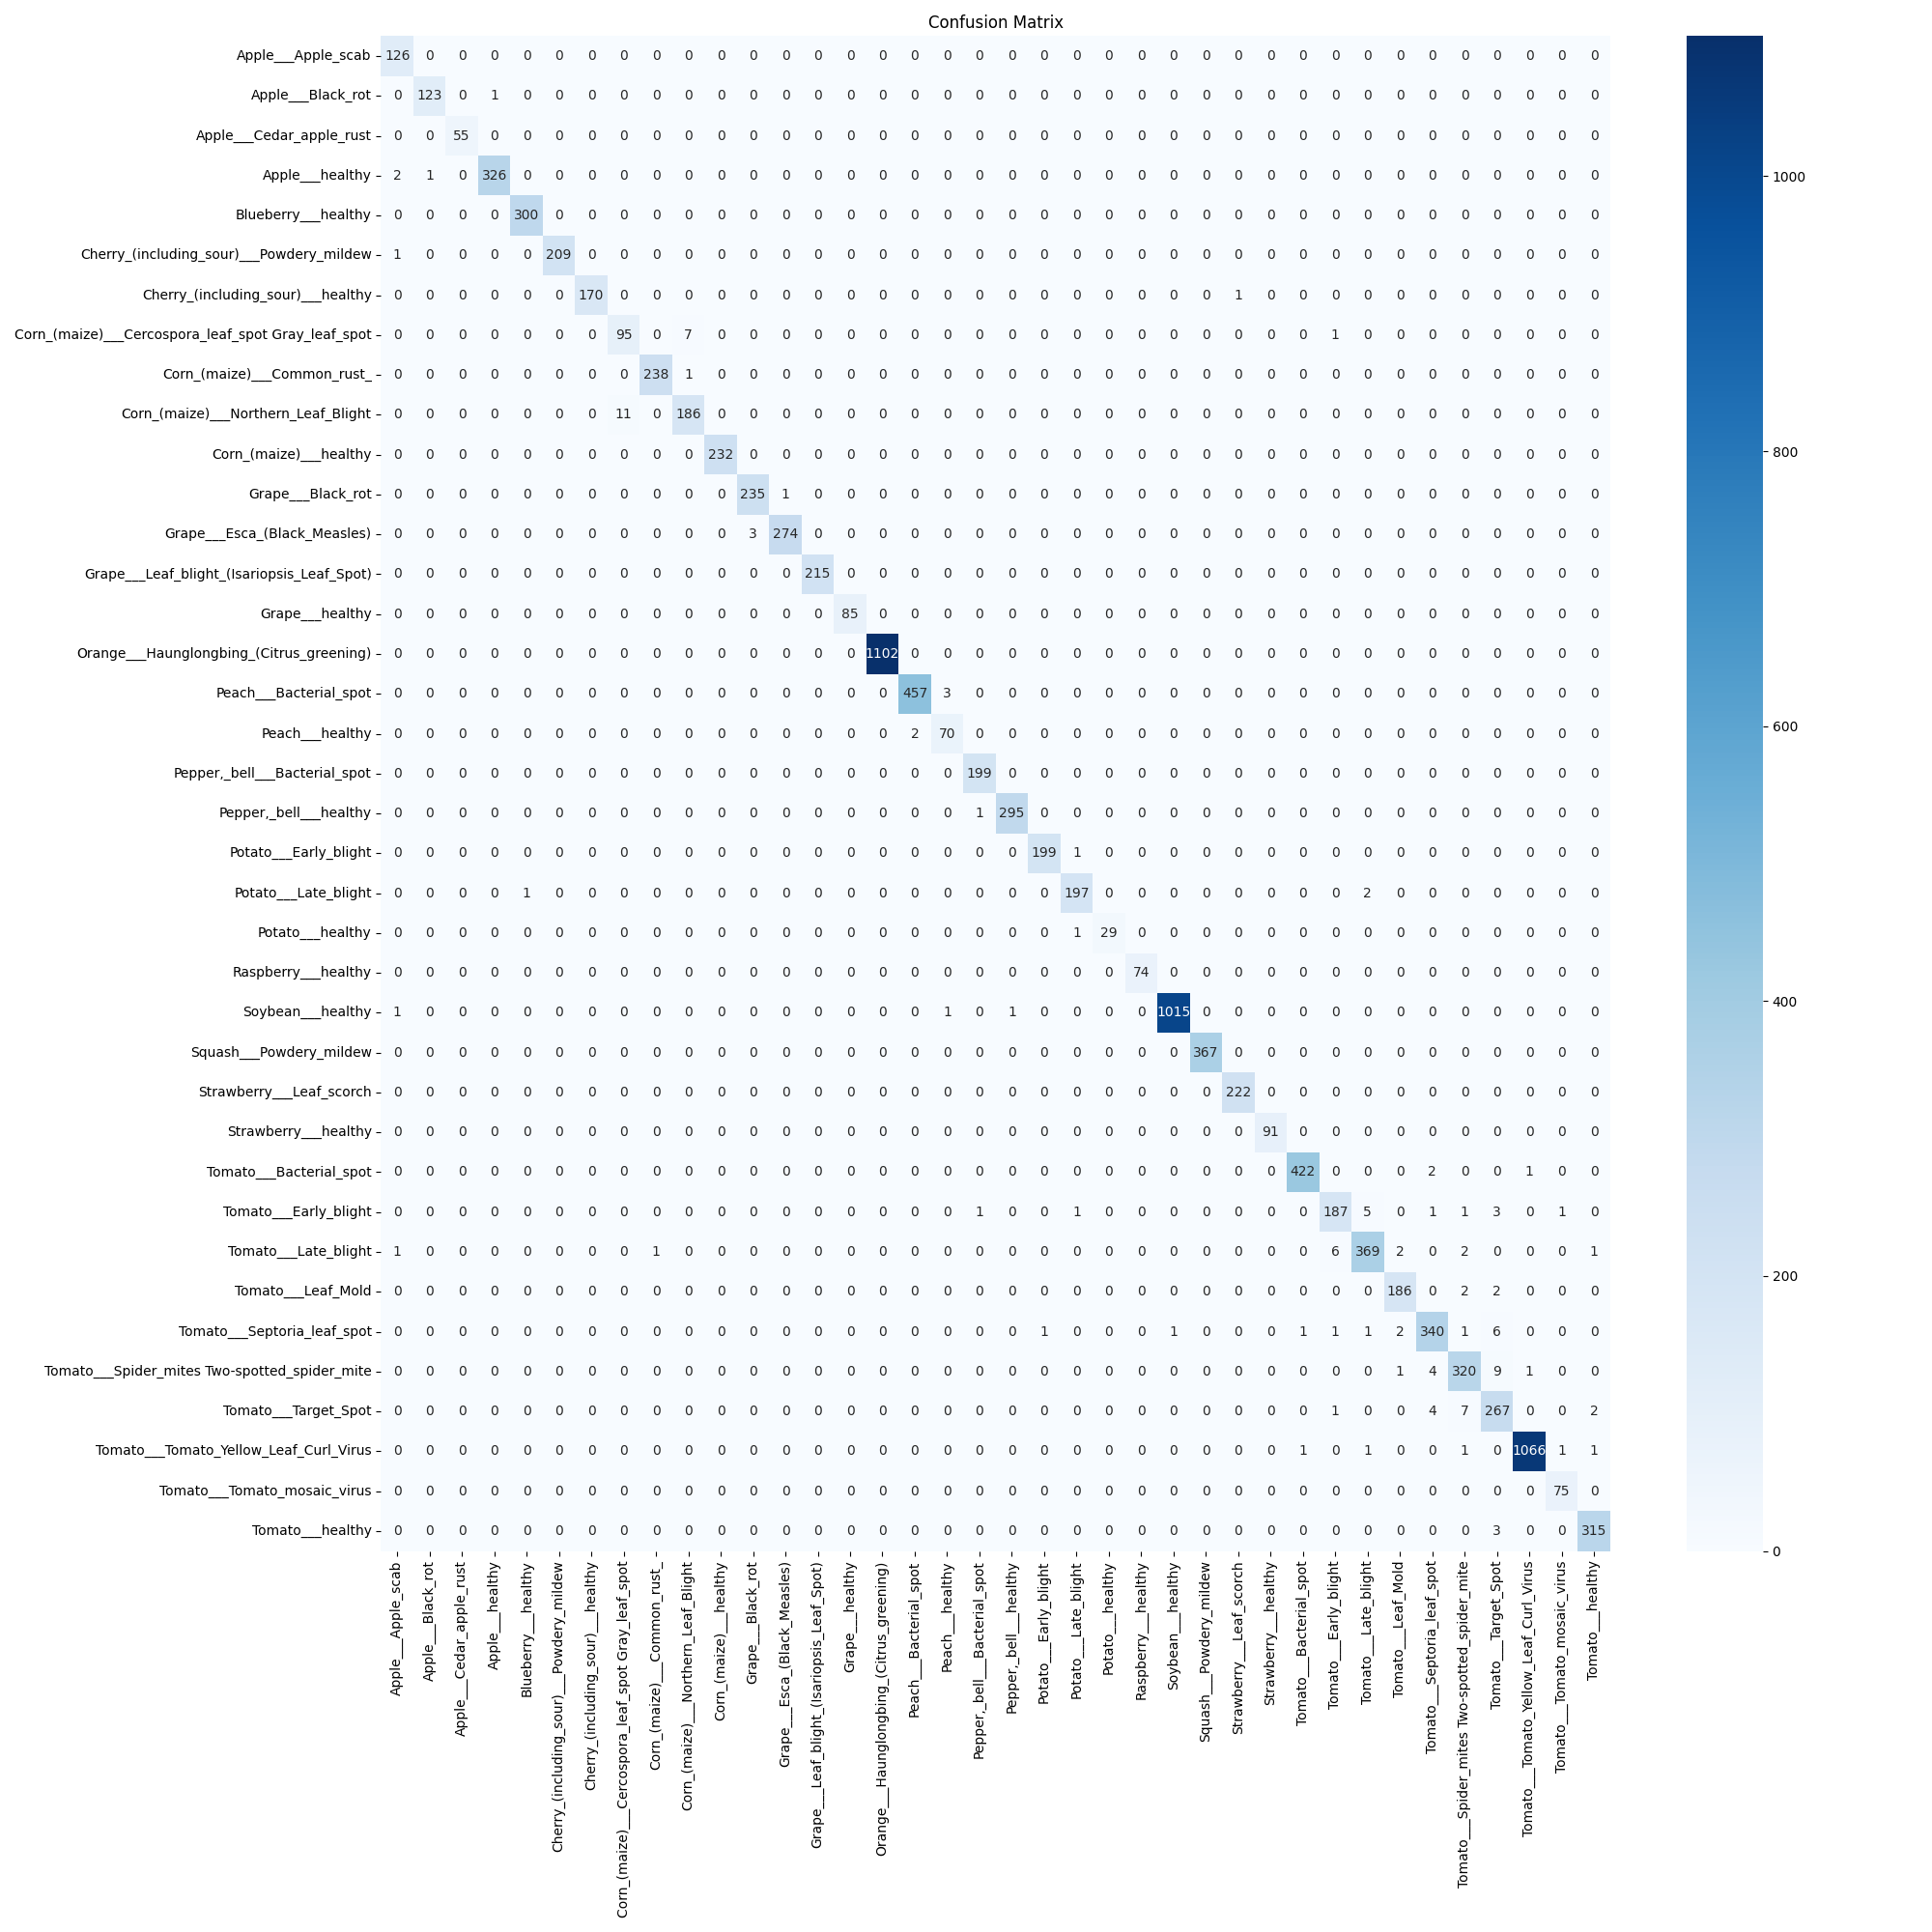

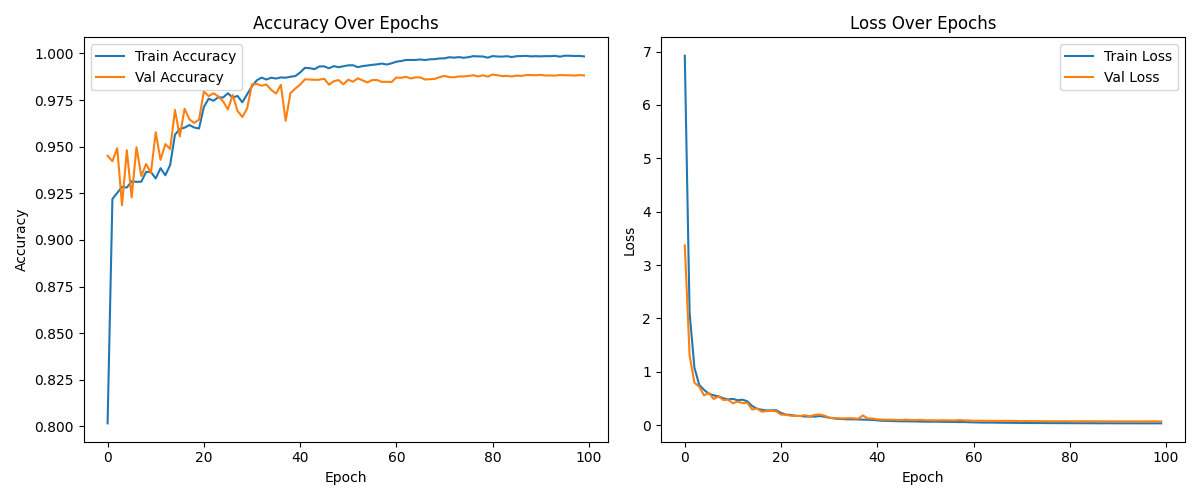


Top 5 Best Performing Classes:
                                   Class  Precision  Recall  F1-Score  Support
                Apple___Cedar_apple_rust        1.0     1.0       1.0       55
                 Squash___Powdery_mildew        1.0     1.0       1.0      367
                         Grape___healthy        1.0     1.0       1.0       85
Orange___Haunglongbing_(Citrus_greening)        1.0     1.0       1.0     1102
                  Corn_(maize)___healthy        1.0     1.0       1.0      232

Top 5 Worst Performing Classes:
                                             Class  Precision   Recall  F1-Score  Support
     Tomato___Spider_mites Two-spotted_spider_mite   0.958084 0.955224  0.956652      335
               Corn_(maize)___Northern_Leaf_Blight   0.958763 0.944162  0.951407      197
                             Tomato___Early_blight   0.954082 0.935000  0.944444      200
                              Tomato___Target_Spot   0.920690 0.950178  0.935201      281
Corn_(maize

In [ ]:
"""
# Tiny NN Training Notebook
Trains a small neural network on PlantVillage features with class weights

Updates:
- All outputs now save directly to Google Drive
- Enhanced visualization and analysis
"""

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/PlantVillage_Project/code/scripts')

# Ensure directories exist (though tiny_nn.py will create them)
!mkdir -p "/content/drive/MyDrive/PlantVillage_Project/models"
!mkdir -p "/content/drive/MyDrive/PlantVillage_Project/logs"

print("Starting Tiny NN Training...")
!python "/content/drive/MyDrive/PlantVillage_Project/code/scripts/tiny_nn.py"

print("\n Training complete! All files are already saved to Google Drive at:")
print("   /content/drive/MyDrive/PlantVillage_Project/")
print("\nFiles available:")
!ls -l "/content/drive/MyDrive/PlantVillage_Project/models/"
!ls -l "/content/drive/MyDrive/PlantVillage_Project/" | grep "tiny_nn_"

# Display the confusion matrix (optional)
from IPython.display import Image
try:
    display(Image(filename='/content/drive/MyDrive/PlantVillage_Project/tiny_nn_confusion_matrix.png'))
except:
    print("Confusion matrix image not found - check Google Drive")

# Display training history (optional)
try:
    display(Image(filename='/content/drive/MyDrive/PlantVillage_Project/tiny_nn_training_history.png'))
except:
    print("Training history image not found - check Google Drive")

# Show class performance (read from CSV)
import pandas as pd
try:
    df = pd.read_csv('/content/drive/MyDrive/PlantVillage_Project/tiny_nn_class_performance.csv')
    print("\nTop 5 Best Performing Classes:")
    print(df.head(5).to_string(index=False))
    print("\nTop 5 Worst Performing Classes:")
    print(df.tail(5).to_string(index=False))
except:
    print("Class performance CSV not found - check Google Drive")
